In [1]:
import pandas as pd
import numpy as np
import random
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config
from visualisation.plotting import coupled_label_plot, color_code_labels
from utils.analysis import get_query_string_hyps_filter, prepare_labels_df, rotate_umap

In [2]:
# Plot settings
xmap = {"n_clusters": "Number of clusters", "eps": "Epsilon", "min_samples": "Minimum number of samples"}
score_name_map = {"calinski_harabasz": "Calinski-Harabasz Score", "silhouette": "Silhouette Score", "davies_bouldin": "Davies-Bouldin Score", "nnoise": "Noise [%]", "nclusters": "Number of Clusters"}
c_blue = sns.color_palette("tab10")[0]
c_orange = sns.color_palette("tab10")[1]

In [3]:
def plot_score(df, x, legend_loc=None):
    fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8.27, 8.27*0.3))

    # Plot lines
    l1 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="calinski_harabasz", ax=axs[0], c=c_blue, label="MinMax")
    l2 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="davies_bouldin", ax=axs[1], c=c_blue, label="MinMax")
    l3 = sns.lineplot(df[df["preprocessing"] == "minmax"], x=x, y="silhouette", ax=axs[2], c=c_blue, label="MinMax")
    
    l4 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="calinski_harabasz", ax=axs[0], c=c_orange, label="MinMax-UMAP")
    l5 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="davies_bouldin", ax=axs[1], c=c_orange, label="MinMax-UMAP")
    l6 = sns.lineplot(df[df["preprocessing"] == "minmax_umap"], x=x, y="silhouette", ax=axs[2], c=c_orange, label="MinMax-UMAP")
   
    # Define labels
    l1.set_xlabel(None)
    l1.set_ylabel(None)
    l1.set_title(r"Calinski-Harabasz Score $\uparrow$", fontsize=11)
    l1.tick_params(labelsize=8)
    l1.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l2.set_xlabel(None)
    l2.set_ylabel(None)
    l2.set_title(r"Davies-Bouldin Score $\downarrow$", fontsize=11)
    l2.tick_params(labelsize=8)
    l2.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    l3.set_xlabel(None)
    l3.set_ylabel(None)
    l3.set_title(r"Silhouette Score $\uparrow$", fontsize=11)
    l3.tick_params(labelsize=8)
    l3.legend(title='Preprocessing', loc=legend_loc, fontsize=8, title_fontsize=8)

    fig.supxlabel(xmap[x], fontsize=11, y=0.04)
    
    plt.tight_layout()

In [4]:
def find_steepest_gradient(df, value_col="calinski_harabasz"):
    """ Find steepest gradient for DBSCAN in an eps-min_samples heatmap using value_col as value column. """
    temp = df.copy()
    
    # Normalize columns for consistent scaling
    temp['eps_norm'] = (temp['eps'] - temp['eps'].min()) / (temp['eps'].max() - temp['eps'].min())
    temp['min_samples_norm'] = (temp['min_samples'] - temp['min_samples'].min()) / (temp['min_samples'].max() - temp['min_samples'].min())
    temp['calinski_norm'] = (temp[value_col] - temp[value_col].min()) / (temp[value_col].max() - temp[value_col].min())
    
    # Pivot to create a 2D grid
    grid = temp.pivot(index='min_samples_norm', columns='eps_norm', values='calinski_norm')
    grid = grid.interpolate(method='linear', axis=0).interpolate(method='linear', axis=1)  # Fill missing values

    # Calculate gradients
    grad_eps, grad_min_samples = np.gradient(grid.values)  # Numerical differentiation

    # Compute gradient magnitude
    grad_magnitude = np.sqrt(grad_eps**2 + grad_min_samples**2)

    # Find the index of the maximum gradient
    max_idx = np.unravel_index(np.argmax(grad_magnitude), grad_magnitude.shape)
    max_min_samples_norm = grid.index[max_idx[0]]
    max_eps_norm = grid.columns[max_idx[1]]

    # Map back to original scale
    max_eps = max_eps_norm * (temp['eps'].max() - temp['eps'].min()) + temp['eps'].min()
    max_min_samples = max_min_samples_norm * (temp['min_samples'].max() - temp['min_samples'].min()) + temp['min_samples'].min()

    return max_eps, max_min_samples

In [5]:
def plot_heatmap(df, x="min_samples", y="eps", color="nclusters", title="Sweep of DBSAN (on original data)", vmax=None, mask=None, annot=True, patch=None):
    """ Plot heatmap using 2 variables and compute steepest gradient. """
    df_temp = df.copy()
    df_temp = df_temp.sort_values([y, x])
    
    idx = df_temp[y].unique()
    cols = df_temp[x].unique()
    field = pd.DataFrame(df_temp[color].to_numpy().reshape(len(idx), len(cols)), index=idx, columns=cols)

    if mask is not None:
        field = field[mask]
            
    h = sns.heatmap(data=field, cbar_kws={'label': score_name_map[color]}, annot=annot, fmt='g', cmap="gray", vmax=vmax)
    # h.figure.axes[-1].yaxis.label.set_size(11)
    plt.gca().invert_yaxis()
    if patch:
        h.add_patch(Rectangle((np.where(cols == patch[1])[0][0], np.where(idx == patch[0])[0][0]), 1, 1, fill=False, edgecolor="red", lw=2))
    plt.xlabel(x)  # , fontsize=11)
    plt.ylabel(y)  # , fontsize=11)
    plt.title(title)  # , fontsize=11)
    plt.tick_params(axis='both', which='minor')  # , labelsize=8)
    plt.tight_layout()

    steepest_gradient_eps, steepest_gradient_min_samples = find_steepest_gradient(df, value_col=color)

    return field, (steepest_gradient_eps, steepest_gradient_min_samples)

In [6]:
# def find_max_diff(field):
#     diff_max = 0
#     col_max0 = 0
#     row_max0 = 0
#     col_max1 = 0
#     row_max1 = 0
    
#     def update(diff_new, col_max0_new, row_max0_new, col_max1_new, row_max1_new, diff_max, col_max0, row_max0, col_max1, row_max1):
#         if diff_new > diff_max:
#             return diff_new, col_max0_new, row_max0_new, col_max1_new, row_max1_new
#         else:
#             return diff_max, col_max0, row_max0, col_max1, row_max1
    
#     for col_idx, col in enumerate(field.columns):
#         for row_idx, row in enumerate(field.index):
#             n = field.iloc[row_idx, col_idx]
    
#             # Init parameters
#             diff_l = 0
#             diff_r = 0
#             diff_u = 0
#             diff_d = 0
    
#             # Compute differences to all neighbouring table entries
#             # Column left
#             if col_idx != 0:
#                 diff_l = abs(n - field.iloc[row_idx, col_idx-1])
#                 diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_l, col_idx, row_idx, col_idx-1, row_idx, diff_max, col_max0, row_max0, col_max1, row_max1)
    
#             # Column right
#             if col_idx != len(field.columns) - 1:
#                 diff_r = abs(n - field.iloc[row_idx, col_idx+1])
#                 diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_r, col_idx, row_idx, col_idx+1, row_idx, diff_max, col_max0, row_max0, col_max1, row_max1)
    
#             # Row up
#             if row_idx != 0:
#                 diff_u = abs(n - field.iloc[row_idx-1, col_idx])
#                 diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_u, col_idx, row_idx, col_idx, row_idx-1, diff_max, col_max0, row_max0, col_max1, row_max1)
    
#             # Row down
#             if row_idx != len(field.index) - 1:
#                 diff_d = abs(n - field.iloc[row_idx+1, col_idx])
#                 diff_max, col_max0, row_max0, col_max1, row_max1 = update(diff_d, col_idx, row_idx, col_idx, row_idx+1, diff_max, col_max0, row_max0, col_max1, row_max1)

#     return diff_max, col_max0, row_max0, col_max1, row_max1

In [7]:
# from pathlib import Path
# # Concatenate all result files
# dfs = []
# for file in Path(config.output_dir_clustering).glob("internal_validation_*_kmeans*.csv"):
#     t = pd.read_csv(file)
#     dfs.append(t)
#     if "Unnamed: 0" in t.columns:
#         print(file)
#         break

# df_kmeans = pd.concat(dfs).reset_index(drop=True)

# # Concatenate all result files
# dfs = []
# for file in Path(config.output_dir_clustering).glob("internal_validation_*_ward*.csv"):
#     t = pd.read_csv(file)
#     dfs.append(t)
#     if "Unnamed: 0" in t.columns:
#         print(file)
#         break

# df_ward = pd.concat(dfs).reset_index(drop=True)

# # Concatenate all result files
# dfs = []
# for file in Path(config.output_dir_clustering).glob("internal_validation_*_dbscan*.csv"):
#     t = pd.read_csv(file)
#     dfs.append(t)
#     if "Unnamed: 0" in t.columns:
#         print(file)
#         break

# df_dbscan = pd.concat(dfs).reset_index(drop=True)

# Load data

In [8]:
# Load scores
df_kmeans = pd.read_csv(f"{config.output_dir_clustering}internal_validation_kmeans.csv")
df_ward = pd.read_csv(f"{config.output_dir_clustering}internal_validation_ward.csv")
df_dbscan = pd.read_csv(f"{config.output_dir_clustering}internal_validation_dbscan.csv")

In [9]:
# Load labels (from iteration 0, store labels from different preproccessings in different columns)
df_kmeans_labels = pd.read_csv(f"{config.output_dir_clustering}labels_kmeans.csv")
df_kmeans_labels = prepare_labels_df(df_kmeans_labels, iteration=0)

df_ward_labels = pd.read_csv(f"{config.output_dir_clustering}labels_ward.csv")
df_ward_labels = prepare_labels_df(df_ward_labels, iteration=0)

df_dbscan_labels = pd.read_csv(f"{config.output_dir_clustering}labels_dbscan_iteration0.csv")
df_dbscan_labels = prepare_labels_df(df_dbscan_labels)

# Compare across algorithms
Using the finally selected hyperparameter combinations, compare the CVIs for the algorithms. 

In [10]:
# Kmeans original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.kmeans_original_hyps, preproc="minmax")
ko = df_kmeans.query(query_str)

# Kmeans embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.kmeans_umap_hyps, preproc="minmax_umap")
ke = df_kmeans.query(query_str)

# Ward original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.ward_original_hyps, preproc="minmax")
wo = df_ward.query(query_str)

# Ward embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.ward_umap_hyps, preproc="minmax_umap")
we = df_ward.query(query_str)

# DBSCAN original
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_original_hyps, preproc="minmax", float_tol=1e-8)
do = df_dbscan.query(query_str)

# DBSCAN embedding
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_umap_hyps, preproc="minmax_umap", float_tol=1e-8)
de = df_dbscan.query(query_str)

In [11]:
print("Average scores")
print("\nKMeans on original: ")
print(f'  Calinski-Harabasz: {ko["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {ko["davies_bouldin"].mean().round(2)}\n  Silhouette: {ko["silhouette"].mean().round(2)}')
print("\nKMeans on UMAP: ")
print(f'  Calinski-Harabasz: {ke["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {ke["davies_bouldin"].mean().round(2)}\n  Silhouette: {ke["silhouette"].mean().round(2)}')

print("\nWard on original: ")
print(f'  Calinski-Harabasz: {wo["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {wo["davies_bouldin"].mean().round(2)}\n  Silhouette: {wo["silhouette"].mean().round(2)}')
print("\nWard on UMAP: ")
print(f'  Calinski-Harabasz: {we["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {we["davies_bouldin"].mean().round(2)}\n  Silhouette: {we["silhouette"].mean().round(2)}')

print("\nDBSCAN on original: ")
print(f'  Calinski-Harabasz: {do["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {do["davies_bouldin"].mean().round(2)}\n  Silhouette: {do["silhouette"].mean().round(2)}')
print("\nDBSCAN on UMAP: ")
print(f'  Calinski-Harabasz: {de["calinski_harabasz"].mean().round()}\n  Davies-Bouldin: {de["davies_bouldin"].mean().round(2)}\n  Silhouette: {de["silhouette"].mean().round(2)}')

Average scores

KMeans on original: 
  Calinski-Harabasz: 57358.0
  Davies-Bouldin: 0.78
  Silhouette: 0.5

KMeans on UMAP: 
  Calinski-Harabasz: 54457.0
  Davies-Bouldin: 0.73
  Silhouette: 0.46

Ward on original: 
  Calinski-Harabasz: 51825.0
  Davies-Bouldin: 0.84
  Silhouette: 0.48

Ward on UMAP: 
  Calinski-Harabasz: 64436.0
  Davies-Bouldin: 0.72
  Silhouette: 0.46

DBSCAN on original: 
  Calinski-Harabasz: 800.0
  Davies-Bouldin: 1.44
  Silhouette: 0.55

DBSCAN on UMAP: 
  Calinski-Harabasz: 2170.0
  Davies-Bouldin: 1.48
  Silhouette: -0.34


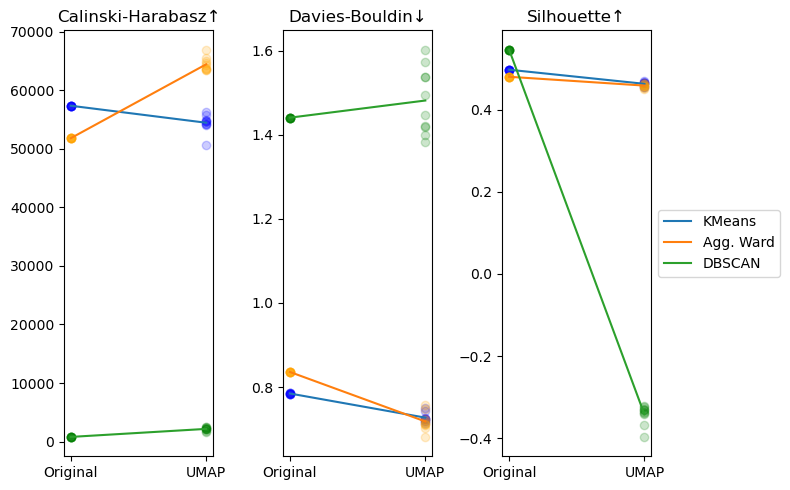

In [12]:
fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 5))
alpha = 0.2
for i, score, score_name in [(0, "calinski_harabasz", "Calinski-Harabasz"), (1, "davies_bouldin", "Davies-Bouldin"), (2, "silhouette", "Silhouette")]:
    title = score_name + "\u2191"
    if score_name == "Davies-Bouldin": 
        title = score_name + "\u2193"
    axs[i].set_title(title)
    axs[i].set_xticks([0, 1], ["Original", "UMAP"])

    axs[i].scatter([0]*len(ko), ko[score], color="blue", alpha=alpha)
    axs[i].scatter([1]*len(ke), ke[score], color="blue", alpha=alpha)
    axs[i].plot([0, 1], [ko[score].mean(), ke[score].mean()], color="tab:blue", label="KMeans")

    axs[i].scatter([0]*len(wo), wo[score], color="orange", alpha=alpha)
    axs[i].scatter([1]*len(we), we[score], color="orange", alpha=alpha)
    axs[i].plot([0, 1], [wo[score].mean(), we[score].mean()], color="tab:orange", label="Agg. Ward")

    axs[i].scatter([0]*len(do), do[score], color="green", alpha=alpha)
    axs[i].scatter([1]*len(de), de[score], color="green", alpha=alpha)
    axs[i].plot([0, 1], [do[score].mean(), de[score].mean()], color="tab:green", label="DBSCAN")
    
axs[i].legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.tight_layout()
#plt.savefig(f"{config.output_dir_plots}score_comparison.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_comparison.png", dpi=1000)
plt.show()

In [13]:
# Correlations between the scores
all = pd.concat([ko, ke, wo, we, do, de])
print(f"Correlation Si-DB: {np.corrcoef(all['silhouette'], all['davies_bouldin'])[0, 1]}")
print(f"Correlation Si-CH: {np.corrcoef(all['silhouette'], all['calinski_harabasz'])[0,1]}")
print(f"Correlation DB-CH: {np.corrcoef(all['calinski_harabasz'], all['davies_bouldin'])[0,1]}")

Correlation Si-DB: -0.5851496016937424
Correlation Si-CH: 0.543917466215719
Correlation DB-CH: -0.9881624172461005


# KMeans

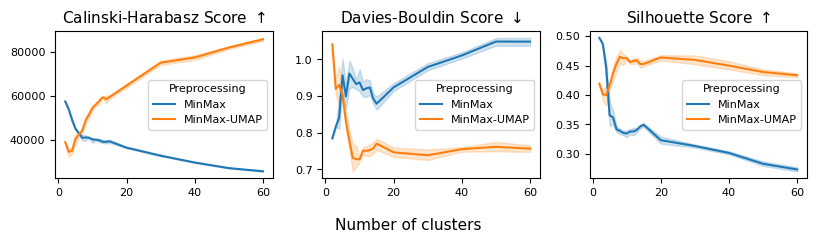

In [14]:
plot_score(df_kmeans, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_kmeans.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_kmeans.png", dpi=1000)
plt.show()

## Plots on original data (MinMax)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:133: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


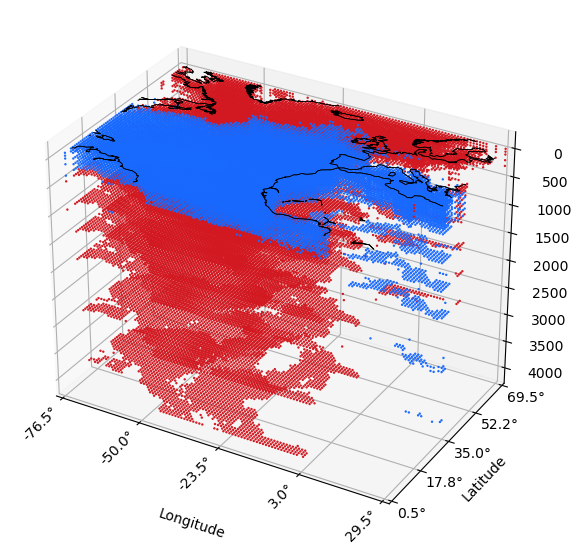

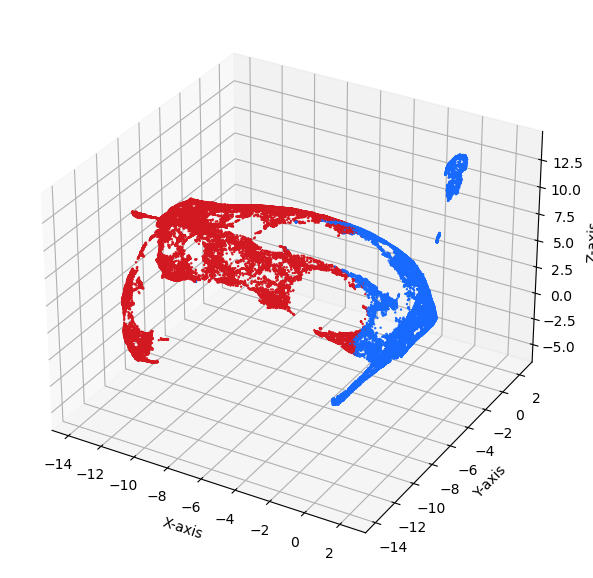

In [15]:
n_clusters = hyp_config.kmeans_original_hyps["n_clusters"]
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_kmeans_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   fontsize=None, ticklabelsize=None, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:133: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


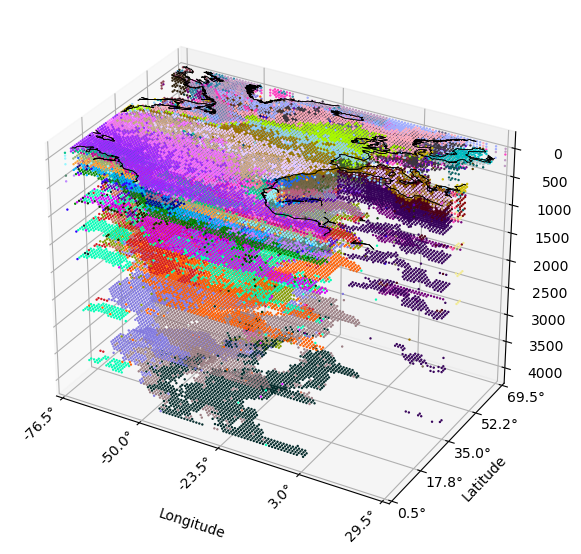

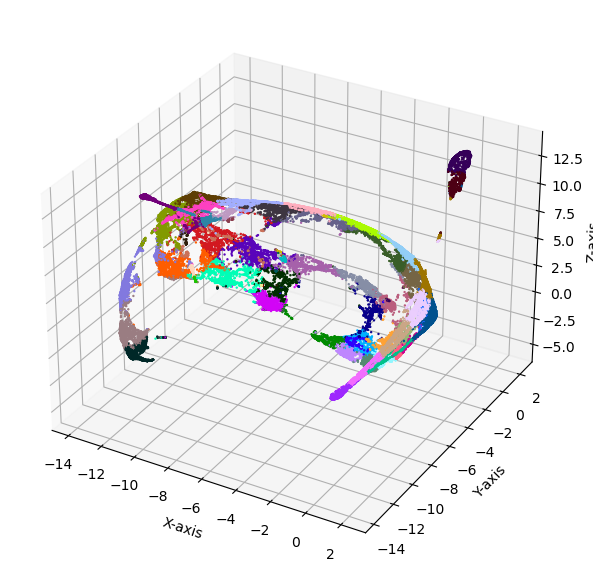

In [16]:
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == 60]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix="_kmeans_original_60", figsize=(6, 6), 
                   fontsize=None, ticklabelsize=None, dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (MinMax-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:133: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


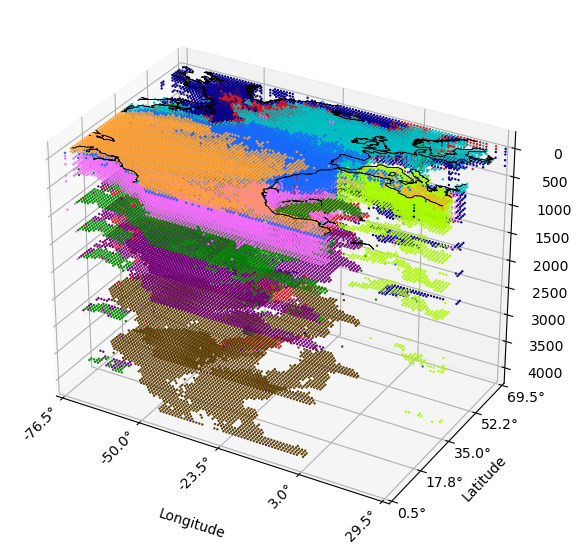

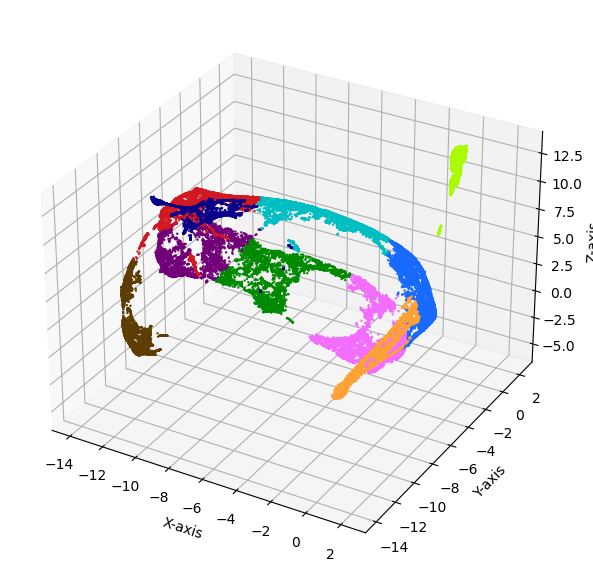

In [17]:
n_clusters = hyp_config.kmeans_umap_hyps["n_clusters"]
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_kmeans_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   fontsize=None, ticklabelsize=None, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:133: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


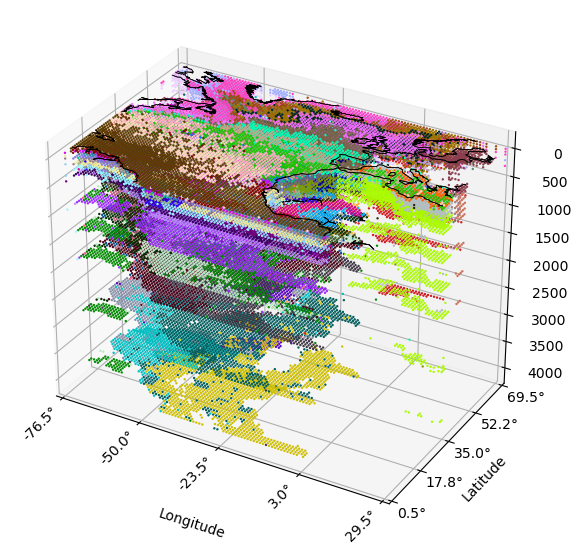

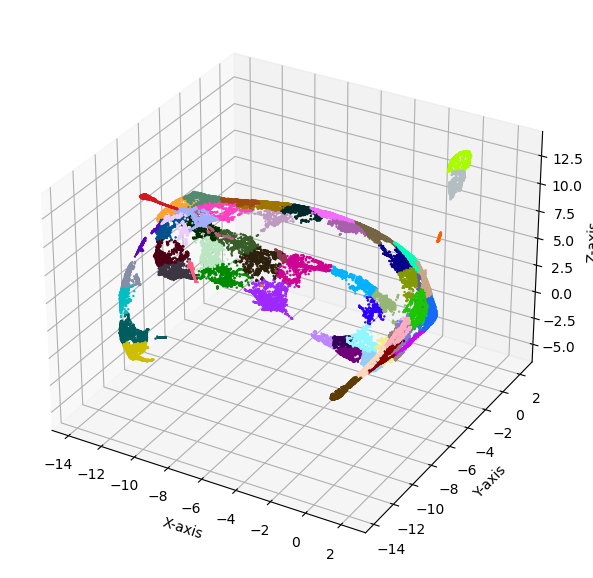

In [18]:
temp = df_kmeans_labels[df_kmeans_labels.n_clusters == 60]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix="_kmeans_umap_60", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   fontsize=None, ticklabelsize=None, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

# Agglomerative Ward

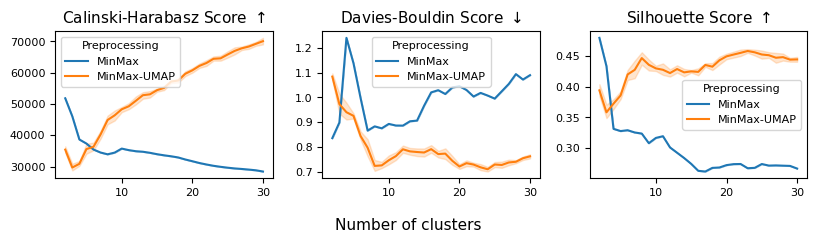

In [19]:
plot_score(df_ward, x="n_clusters")
# plt.savefig(f"{config.output_dir_plots}score_ward.png")
plt.savefig(f"{config.output_dir_plots_high_res}score_ward.png", dpi=1000)
plt.show()

## Plots on original data (MinMax)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:133: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


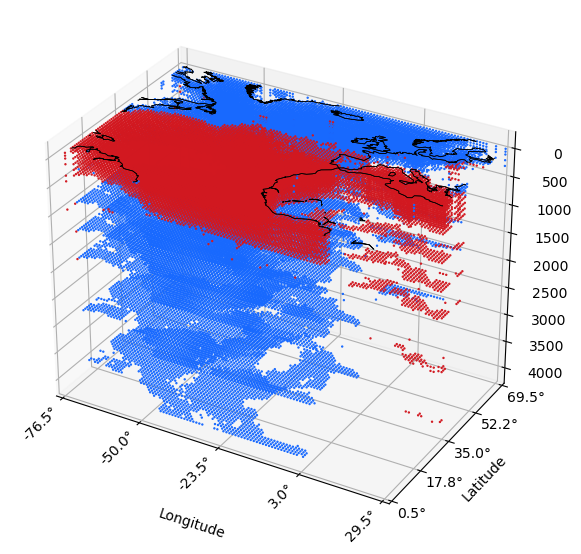

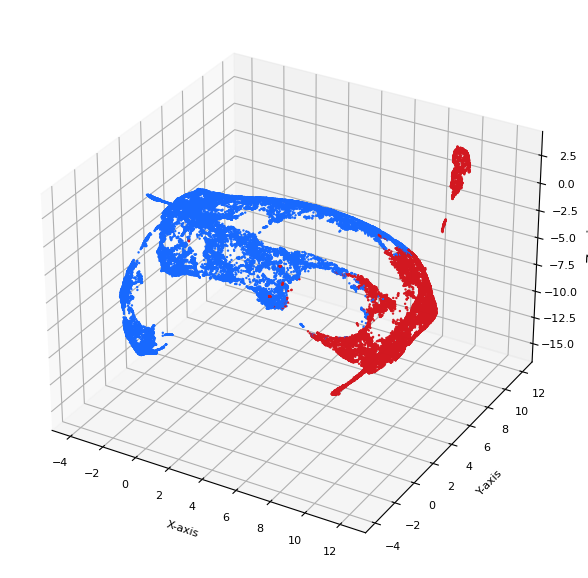

In [20]:
n_clusters = hyp_config.ward_original_hyps["n_clusters"]
temp = df_ward_labels[df_ward_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=-1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_ward_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (MinMax-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:133: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


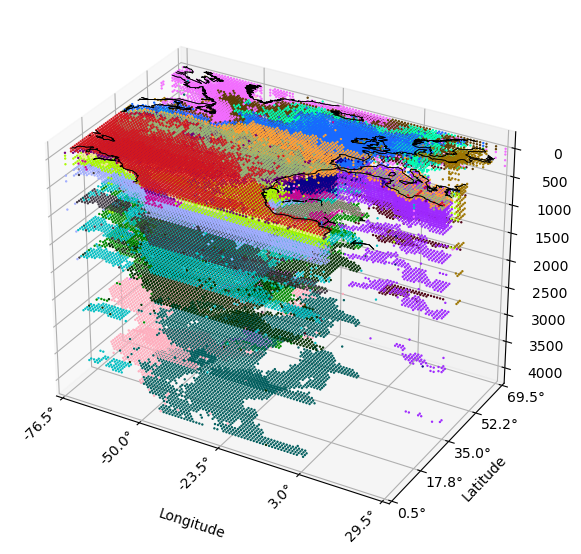

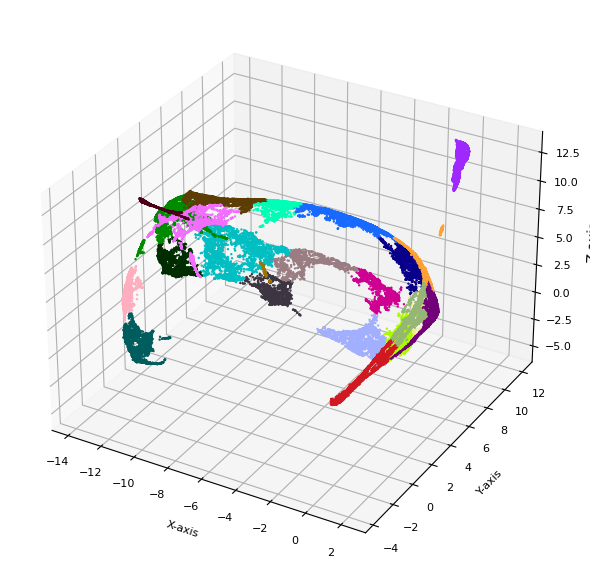

In [21]:
n_clusters = hyp_config.ward_umap_hyps["n_clusters"]
temp = df_ward_labels[df_ward_labels.n_clusters == n_clusters]
temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=180, y=0, z=0, factor=-1)  # Rotate UMAP 
# temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="minmax_umap")
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_ward_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

# DBSCAN

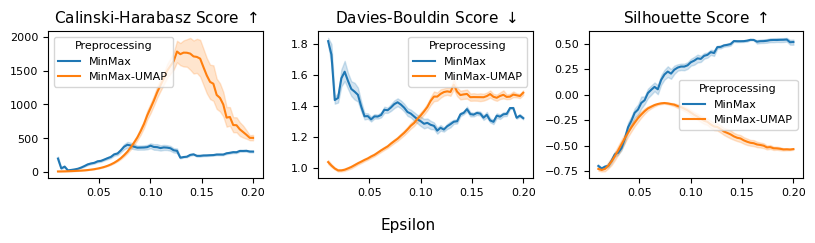

In [22]:
plot_score(df_dbscan, x="eps")
plt.savefig(f"{config.output_dir_plots}score_dbscan_eps.png")
plt.show()

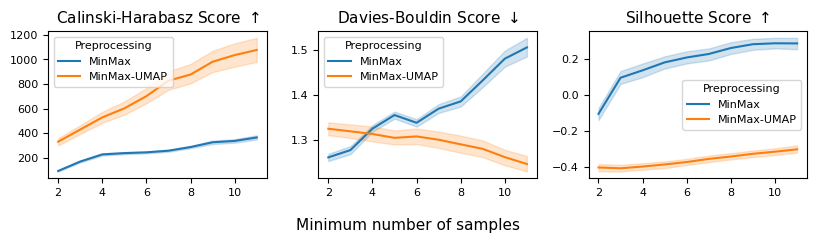

In [23]:
plot_score(df_dbscan, x="min_samples")
plt.savefig(f"{config.output_dir_plots}score_dbscan_min_samples.png")
plt.show()

## Heatmaps
The tuning of 2 parameters instead of one is more complex due to the interaction between the parameters. Therefore, considering plots displaying only one parameter is less descriptive of the actual behaviour. Therefore, we plot the following heatmap.

In [24]:
df_dbscan = df_dbscan.drop("Unnamed: 0", axis=1)

In [25]:
# Average scores over iterations
df_dbscan_i = df_dbscan.groupby(["eps", "min_samples", "preprocessing", "clustering"]).mean().drop("iteration", axis=1).reset_index()

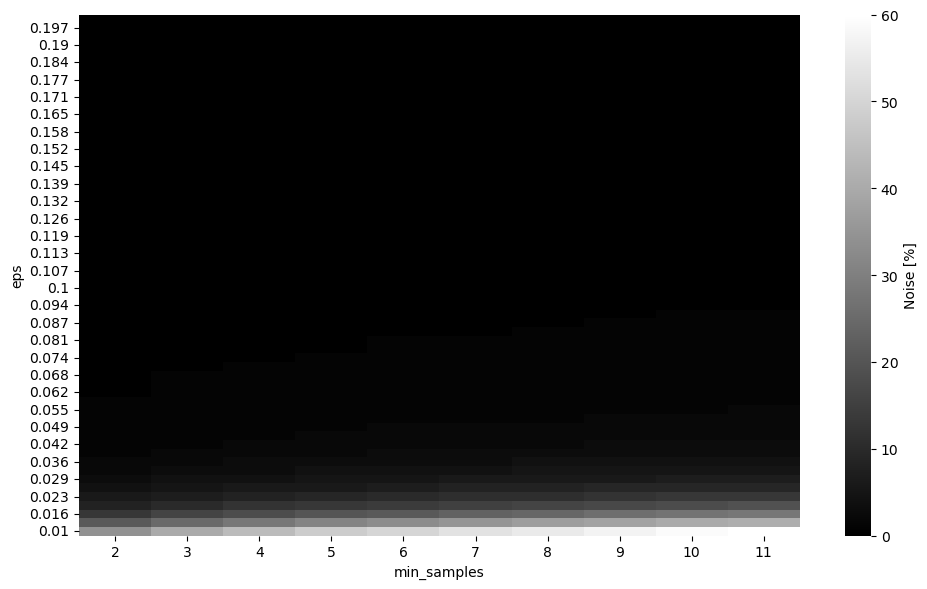

Maximum gradient for nnoise at (eps, min_samples) = (0.01, 9.0)


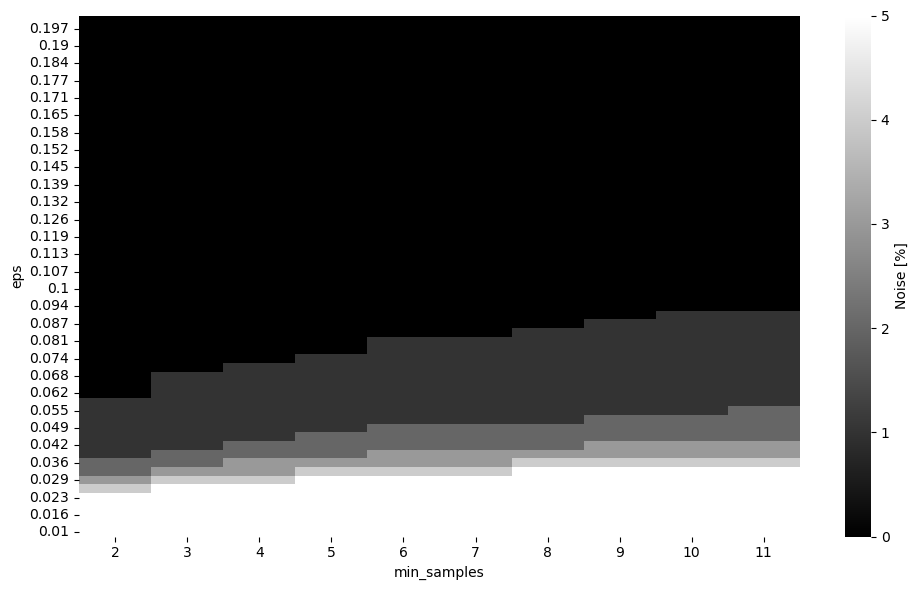

Maximum gradient (nnoise <=5) at (eps, min_samples) = (0.01, 9.0)


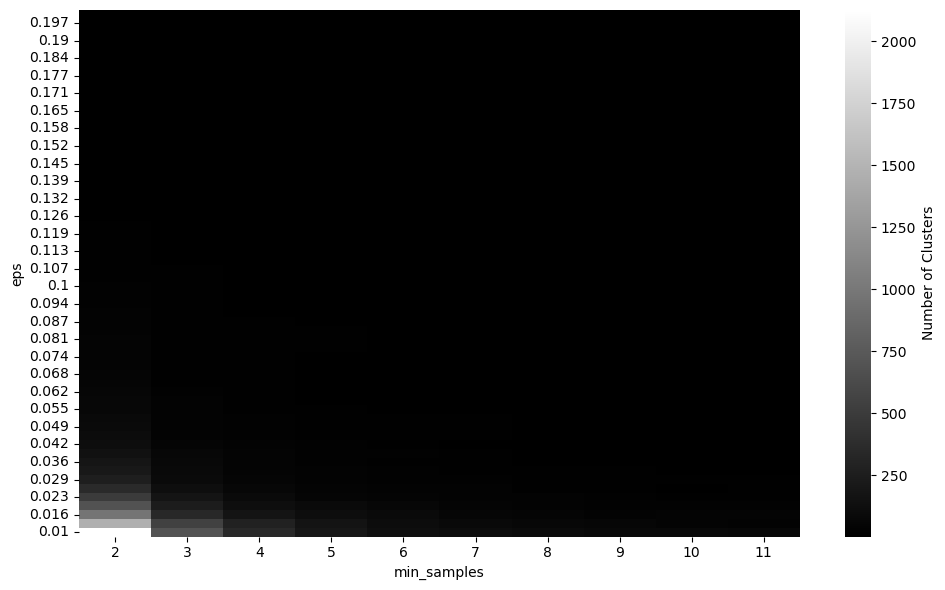

Maximum gradient at (eps, min_samples) = (0.01, 2.0)


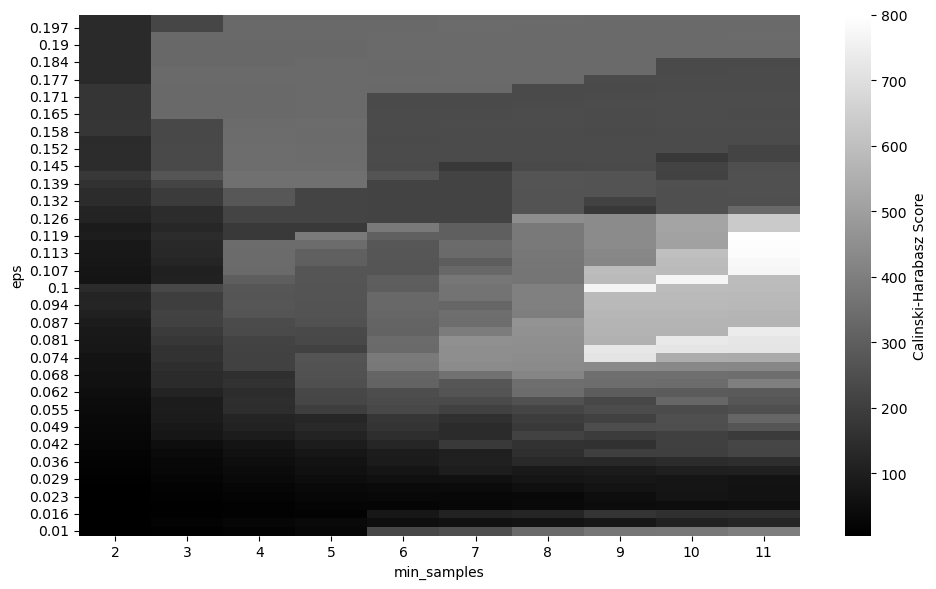

Maximum Calinski-Harabasz score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
698  0.119           11        minmax     dbscan        4.0         14.37246   

     score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  \
698   22.848177       0.546            1.44              800.0     0.0   

     confetti  
698       0.0  


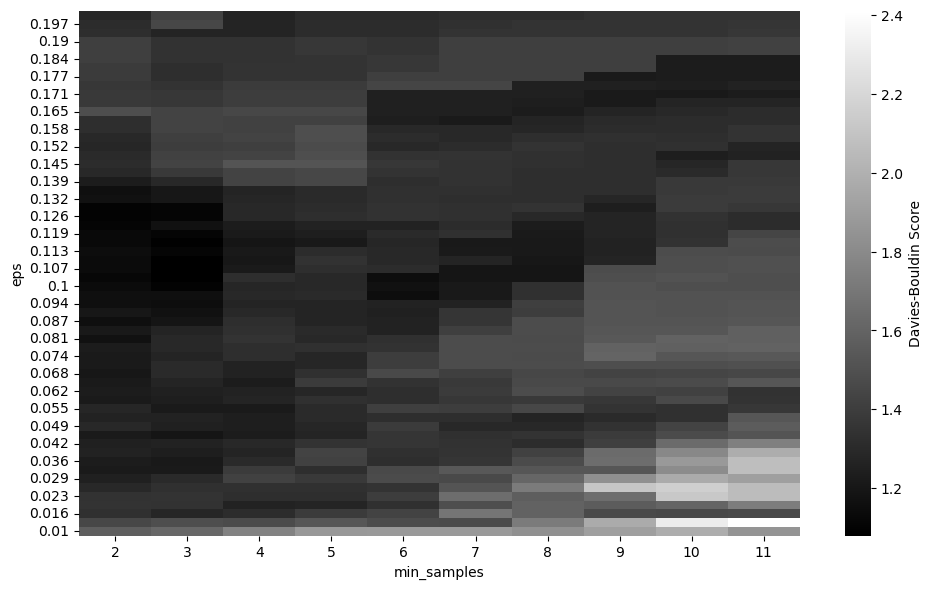

Minimum Davies-Bouldin score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
582  0.103            3        minmax     dbscan       12.0        11.633182   
602  0.107            3        minmax     dbscan       12.0        12.192453   
622  0.110            3        minmax     dbscan       11.0        12.653913   

     score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  \
582   22.069961       0.383            1.08              108.0     0.0   
602   22.403144       0.384            1.08              107.0     0.0   
622   22.303574       0.380            1.08              120.0     0.0   

     confetti  
582       0.0  
602       0.0  
622       0.0  


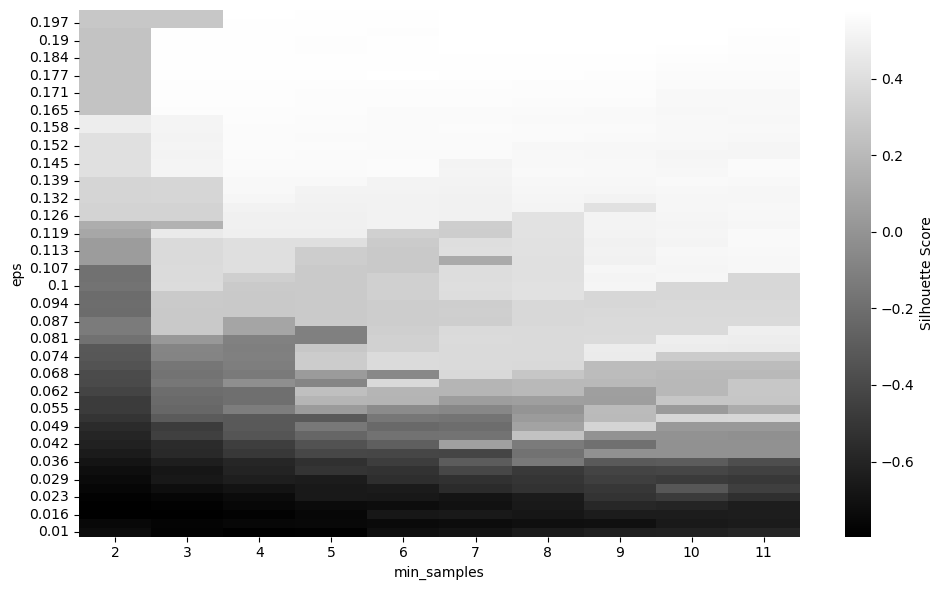

Maximum Silhouette score here:       eps  min_samples preprocessing clustering  nclusters  clustering_time  \
1190  0.2            7        minmax     dbscan        3.0        26.932061   
1194  0.2            9        minmax     dbscan        3.0        26.422828   
1196  0.2           10        minmax     dbscan        3.0        26.963521   
1198  0.2           11        minmax     dbscan        3.0        26.828361   

      score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  \
1190   27.497067       0.579            1.32              338.0     0.0   
1194   28.171229       0.579            1.34              337.0     0.0   
1196   28.381328       0.579            1.34              337.0     0.0   
1198   28.331003       0.579            1.34              337.0     0.0   

      confetti  
1190       0.0  
1194       0.0  
1196       0.0  
1198       0.0  


In [26]:
# Plot score heatmap for clustering on original and scores on original
preproc = "minmax"

plt.rcParams["figure.figsize"] = (10, 6)
# sns.set(font_scale=1.4)

# prepare and filter data
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
temp.nnoise = round(temp.nnoise*100/49030)
t = temp[temp.nnoise <= 5]

# Noise fraction
field_n, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", annot=False)
plt.show()
print(f"Maximum gradient for nnoise at (eps, min_samples) = {steepest_gradient}")

# Noise fraction (with mask for 5%)
field_5, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", mask=field_n <= 5, annot=False)
plt.show()
print(f"Maximum gradient (nnoise <=5) at (eps, min_samples) = {steepest_gradient}")

# Number of clusters
field, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_nclusters.png")
plt.show()
print(f"Maximum gradient at (eps, min_samples) = {steepest_gradient}")

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False)
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
# print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski == t.calinski.max()]}")

# Davies-Bouldin
field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title="", annot=False)
plt.show()
print(f"Minimum Davies-Bouldin score here: {temp[temp.davies_bouldin == temp.davies_bouldin.min()]}")
# print(f"Minimum Davies-Bouldin score (where nnoise<=5) here: {t[t.davies_bouldin == t.davies_bouldin.min()]}")

# Silhouette
field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title="", annot=False)
plt.show()
print(f"Maximum Silhouette score here: {temp[temp.silhouette == temp.silhouette.max()]}")
# print(f"Maximum Silhouette score (where nnoise<=5) here: {t[t.silhouette == t.silhouette.max()]}")

In [27]:
eps_array = config.algorithms_and_hyps["dbscan"][1]["eps"]

print("Hyperparameters for DBSCAN on minmax (original) data")
ch_max = temp[temp["calinski_harabasz"] == temp["calinski_harabasz"].max()].iloc[0]
sh_max = temp[temp["silhouette"] == temp["silhouette"].max()].iloc[0]
db_min = temp[temp["davies_bouldin"] == temp["davies_bouldin"].min()].iloc[0]
nc_gradient = find_steepest_gradient(temp, value_col="nclusters")
nc_steep = temp[(temp.min_samples == nc_gradient[1]) & (temp.eps.round(3) == nc_gradient[0].round(3))].iloc[0]

print(f"  Highest CH score: eps={eps_array[np.abs(eps_array - ch_max.eps).argmin()].round(8)}, min_samples={ch_max['min_samples']}, CH={ch_max['calinski_harabasz']}, DB={ch_max['davies_bouldin'].round(2)}, SH={ch_max.silhouette.round(2)}, n_clusters={ch_max.nclusters}, nnoise={ch_max.nnoise}")
print(f"  Lowest DB score: eps={eps_array[np.abs(eps_array - db_min.eps).argmin()].round(8)}, min_samples={db_min['min_samples']}, CH={db_min['calinski_harabasz']}, DB={db_min['davies_bouldin'].round(2)}, SH={db_min.silhouette.round(2)}, n_clusters={db_min.nclusters}, nnoise={db_min.nnoise}")
print(f"  Highest SH score: eps={eps_array[np.abs(eps_array - sh_max.eps).argmin()].round(8)}, min_samples={sh_max['min_samples']}, CH={sh_max['calinski_harabasz']}, DB={sh_max['davies_bouldin'].round(2)}, SH={sh_max.silhouette.round(2)}, n_clusters={sh_max.nclusters}, nnoise={sh_max.nnoise}")
print(f"  Steepest #clusters gradient: eps={eps_array[np.abs(eps_array - nc_steep.eps).argmin()].round(8)}, min_samples={nc_steep['min_samples']}, CH={nc_steep['calinski_harabasz']}, DB={nc_steep['davies_bouldin'].round(2)}, SH={nc_steep.silhouette.round(2)}, n_clusters={nc_steep.nclusters}, nnoise={nc_steep.nnoise}")

Hyperparameters for DBSCAN on minmax (original) data
  Highest CH score: eps=0.11949153, min_samples=11, CH=800.0, DB=1.44, SH=0.55, n_clusters=4.0, nnoise=0.0
  Lowest DB score: eps=0.10338983, min_samples=3, CH=108.0, DB=1.08, SH=0.38, n_clusters=12.0, nnoise=0.0
  Highest SH score: eps=0.2, min_samples=7, CH=338.0, DB=1.32, SH=0.58, n_clusters=3.0, nnoise=0.0
  Steepest #clusters gradient: eps=0.01, min_samples=2, CH=5.0, DB=1.57, SH=-0.73, n_clusters=2127.0, nnoise=34.0


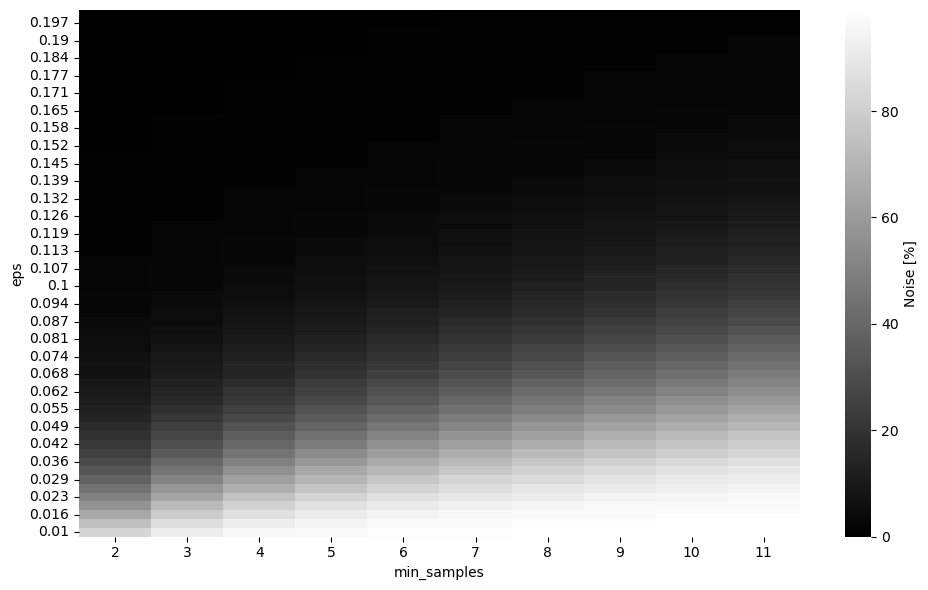

Maximum noise gradient at (eps, min_samples) = (0.02, 2.0)


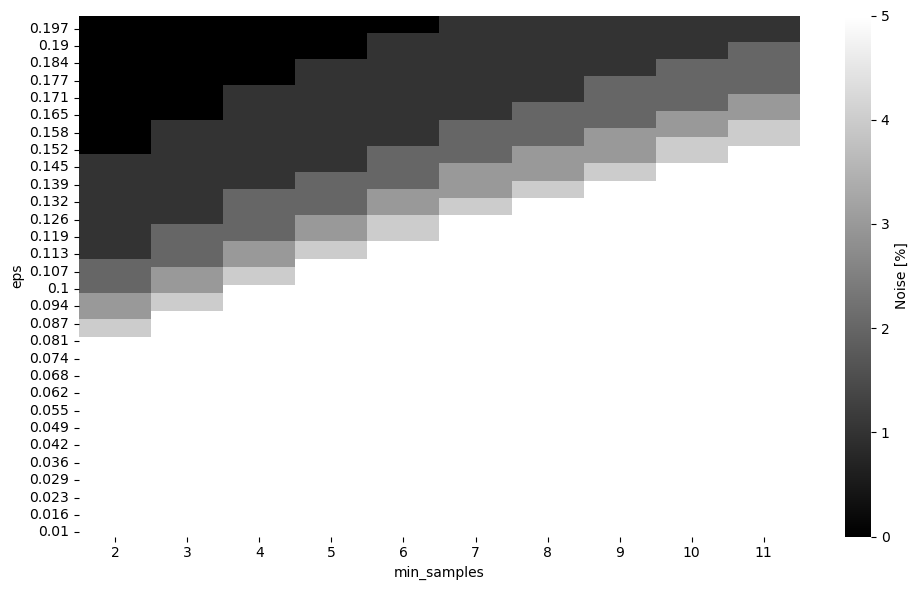

Maximum noise<5% gradient at (eps, min_samples) = (0.02, 2.0)


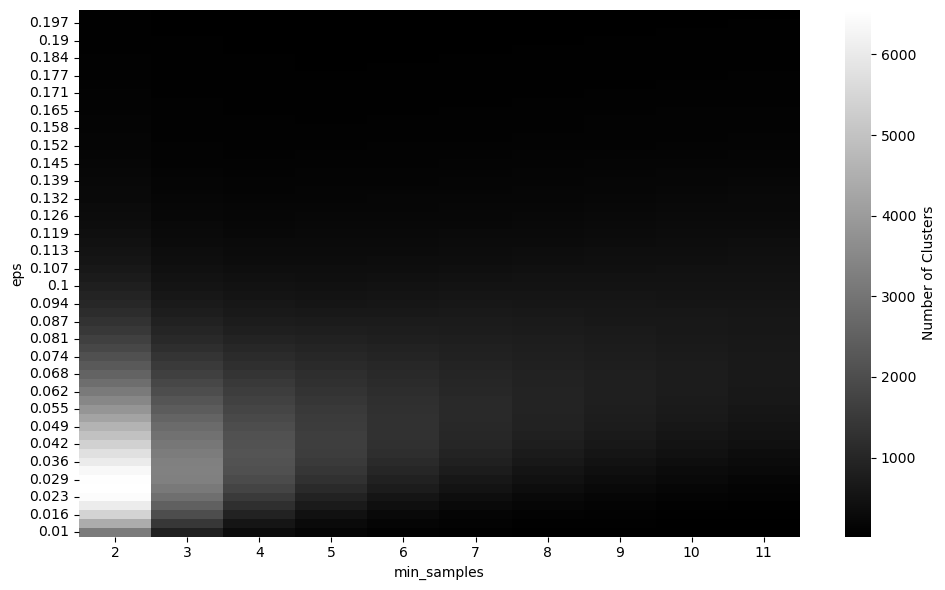

Maximum nclusters gradient at (eps, min_samples) = (0.02, 2.0)


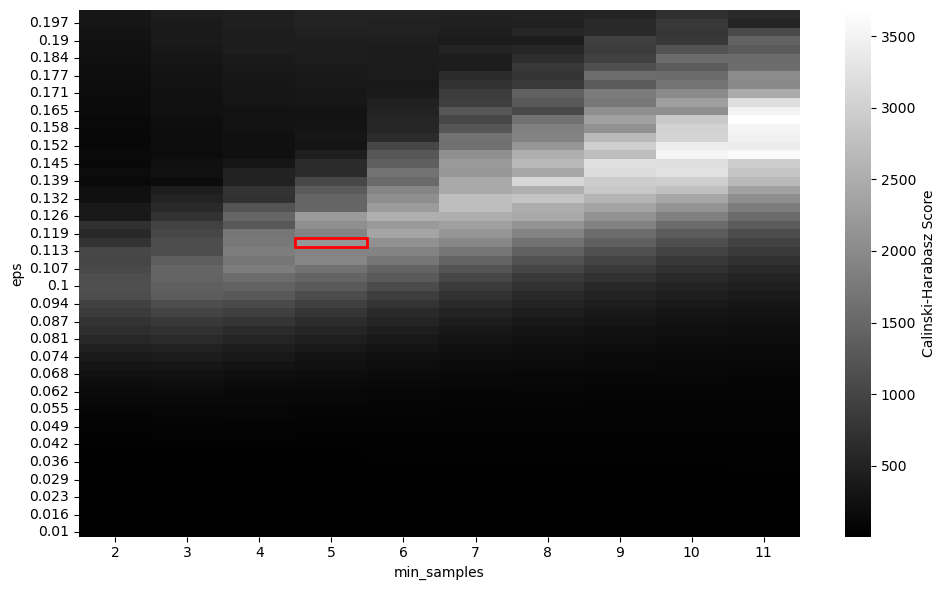

Maximum Calinski-Harabasz score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
959  0.161           11   minmax_umap     dbscan      110.0        14.933276   

     score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  \
959   35.704274      -0.233            1.53             3684.0     4.0   

     confetti  
959      50.0  


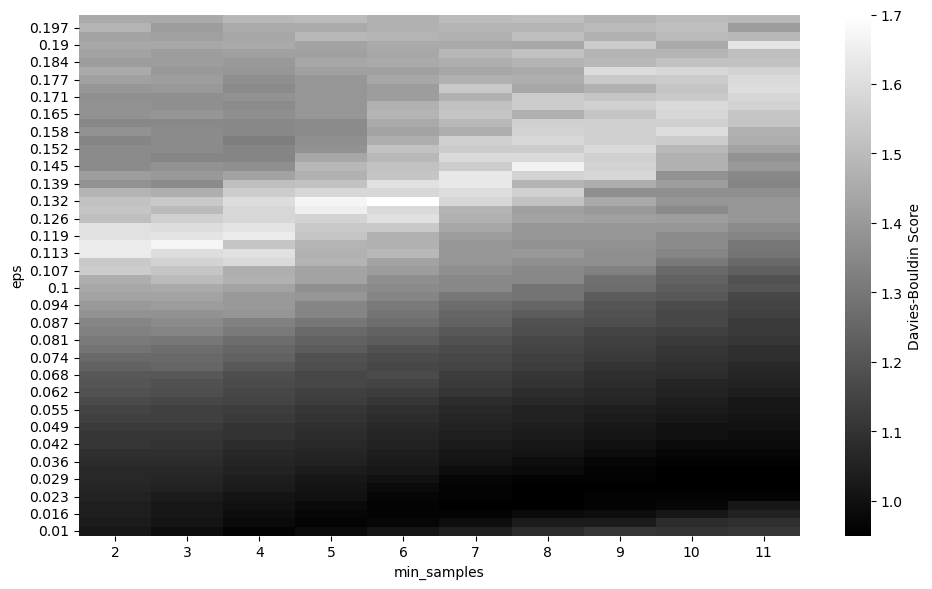

Minimum Davies-Bouldin score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
71   0.020            7   minmax_umap     dbscan      262.0        15.837627   
73   0.020            8   minmax_umap     dbscan      177.0        15.968132   
93   0.023            8   minmax_umap     dbscan      258.0        15.646925   
113  0.026            8   minmax_umap     dbscan      357.0        16.854796   
115  0.026            9   minmax_umap     dbscan      259.0        15.998840   
117  0.026           10   minmax_umap     dbscan      190.0        16.354989   
119  0.026           11   minmax_umap     dbscan      137.0        15.413217   
137  0.029           10   minmax_umap     dbscan      253.0        15.398955   
139  0.029           11   minmax_umap     dbscan      193.0        15.532114   
157  0.033           10   minmax_umap     dbscan      324.0        15.349798   
159  0.033           11   minmax_umap     dbscan      250.0        15.244556   

    

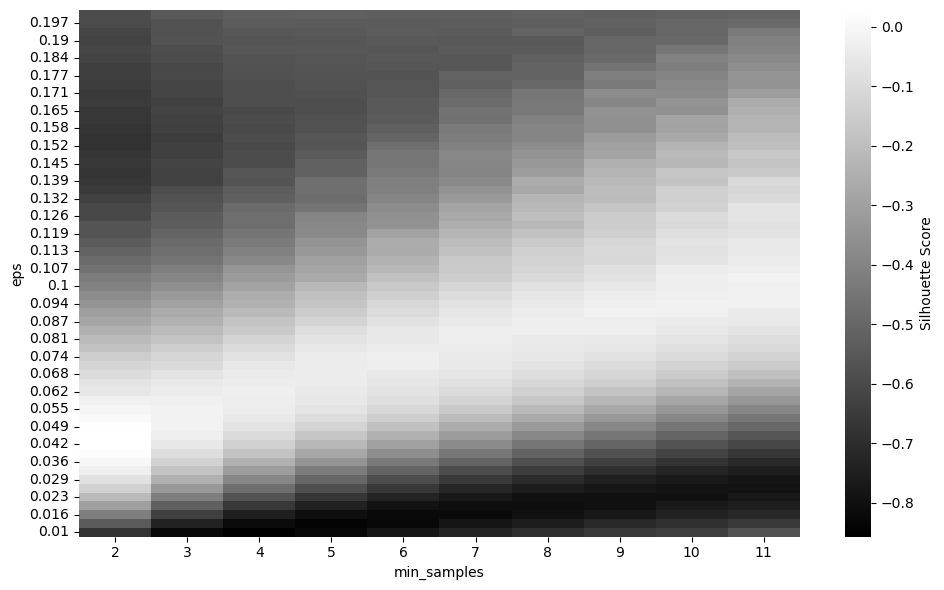

Maximum Silhouette score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
201  0.042            2   minmax_umap     dbscan     5356.0        15.779515   
221  0.045            2   minmax_umap     dbscan     4963.0        15.968405   

     score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  \
201   35.789181       0.028            1.11               35.0    22.0   
221   43.408401       0.028            1.11               44.0    19.0   

     confetti  
201     97.46  
221     97.09  


In [28]:
# Plot score heatmap for clustering on embedding and scores on embedding
preproc = "minmax_umap"

plt.rcParams["figure.figsize"] = (10, 6)
# sns.set(font_scale=1.4)

temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()
temp.nnoise = round(temp.nnoise*100/49030)
t = temp[temp.nnoise <= 5]

# Noise fraction
field_n, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", annot=False)  # , vmax=5)
plt.show()
print(f"Maximum noise gradient at (eps, min_samples) = {steepest_gradient}")

# Noise fraction (with mask for 5%)
field_5, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nnoise", title="", mask=field_n <= 5, annot=False)
plt.show()
print(f"Maximum noise<5% gradient at (eps, min_samples) = {steepest_gradient}")

# Number of clusters
field, steepest_gradient = plot_heatmap(temp, x="min_samples", y="eps", color="nclusters", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_nclusters.png")
plt.show()
print(f"Maximum nclusters gradient at (eps, min_samples) = {steepest_gradient}")

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False, patch=(np.round(hyp_config.dbscan_umap_hyps["eps"], 3), hyp_config.dbscan_umap_hyps["min_samples"]))
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_calinski.png")
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
#print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski_harabasz == t.calinski_harabasz.max()]}")

# Davies-Bouldin
field_db, vs_db = plot_heatmap(temp, x="min_samples", y="eps", color="davies_bouldin", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_davies_bouldin.png")
plt.show()
print(f"Minimum Davies-Bouldin score here: {temp[temp.davies_bouldin == temp.davies_bouldin.min()]}")
#print(f"Minimum Davies-Bouldin score (where nnoise<=5) here: {t[t.davies_bouldin == t.davies_bouldin.min()]}")

# Silhouette
field_s, vs_s = plot_heatmap(temp, x="min_samples", y="eps", color="silhouette", title="", annot=False)
plt.savefig(f"{config.output_dir_plots}{preproc}_dbscan_sweep_silhouette.png")
plt.show()
print(f"Maximum Silhouette score here: {temp[temp.silhouette == temp.silhouette.max()]}")
#print(f"Maximum Silhouette score (where nnoise<=5) here: {t[t.silhouette == t.silhouette.max()]}")


In [29]:
eps_array = config.algorithms_and_hyps["dbscan"][1]["eps"]

print("Hyperparameters for DBSCAN on minmax_umap (embedded) data")
ch_max = temp[temp["calinski_harabasz"] == temp["calinski_harabasz"].max()].iloc[0]
sh_max = temp[temp["silhouette"] == temp["silhouette"].max()].iloc[0]
db_min = temp[temp["davies_bouldin"] == temp["davies_bouldin"].min()].iloc[0]
nc_gradient = find_steepest_gradient(temp, value_col="nclusters")
nc_steep = temp[(temp.min_samples == nc_gradient[1]) & (temp.eps.round(3) == nc_gradient[0].round(3))].iloc[0]

print(f"  Highest CH score: eps={eps_array[np.abs(eps_array - ch_max.eps).argmin()].round(8)}, min_samples={ch_max['min_samples']}, CH={ch_max['calinski_harabasz']}, DB={ch_max['davies_bouldin'].round(2)}, SH={ch_max.silhouette.round(2)}, n_clusters={ch_max.nclusters}, nnoise={ch_max.nnoise}")
print(f"  Lowest DB score: eps={eps_array[np.abs(eps_array - db_min.eps).argmin()].round(8)}, min_samples={db_min['min_samples']}, CH={db_min['calinski_harabasz']}, DB={db_min['davies_bouldin'].round(2)}, SH={db_min.silhouette.round(2)}, n_clusters={db_min.nclusters}, nnoise={db_min.nnoise}")
print(f"  Highest SH score: eps={eps_array[np.abs(eps_array - sh_max.eps).argmin()].round(8)}, min_samples={sh_max['min_samples']}, CH={sh_max['calinski_harabasz']}, DB={sh_max['davies_bouldin'].round(2)}, SH={sh_max.silhouette.round(2)}, n_clusters={sh_max.nclusters}, nnoise={sh_max.nnoise}")
print(f"  Steepest #clusters gradient: eps={eps_array[np.abs(eps_array - nc_steep.eps).argmin()].round(8)}, min_samples={nc_steep['min_samples']}, CH={nc_steep['calinski_harabasz']}, DB={nc_steep['davies_bouldin'].round(2)}, SH={nc_steep.silhouette.round(2)}, n_clusters={nc_steep.nclusters}, nnoise={nc_steep.nnoise}")

Hyperparameters for DBSCAN on minmax_umap (embedded) data
  Highest CH score: eps=0.16135593, min_samples=11, CH=3684.0, DB=1.53, SH=-0.23, n_clusters=110.0, nnoise=4.0
  Lowest DB score: eps=0.01966102, min_samples=7, CH=17.0, DB=0.95, SH=-0.81, n_clusters=262.0, nnoise=93.0
  Highest SH score: eps=0.04220339, min_samples=2, CH=35.0, DB=1.11, SH=0.03, n_clusters=5356.0, nnoise=22.0
  Steepest #clusters gradient: eps=0.01966102, min_samples=2, CH=6.0, DB=1.04, SH=-0.31, n_clusters=6053.0, nnoise=57.0


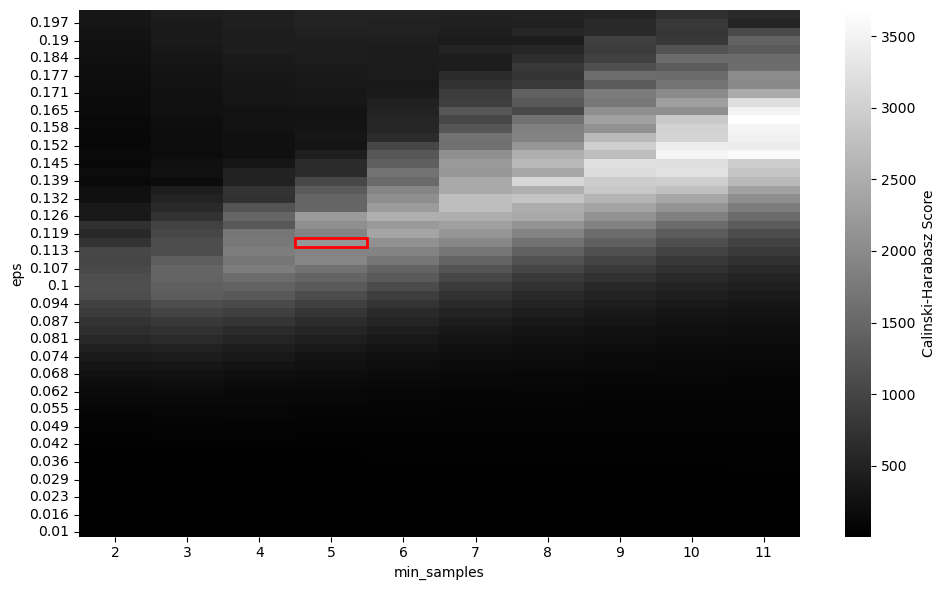

Maximum Calinski-Harabasz score here:        eps  min_samples preprocessing clustering  nclusters  clustering_time  \
959  0.161           11   minmax_umap     dbscan      110.0        14.933276   

     score_time  silhouette  davies_bouldin  calinski_harabasz  nnoise  \
959   35.704274      -0.233            1.53             3684.0  1718.1   

     confetti  
959      50.0  


In [30]:
# Plot score heatmap for other preprocessing
preproc = "minmax_umap"

# Figure size
# plt.rcParams["figure.figsize"] = (8.27, 8.27*0.6)  # (15, 6)
plt.rcParams["figure.figsize"] = (10, 10*0.6)  # (15, 6)


# Prepare and filter data
temp = df_dbscan_i[df_dbscan_i.preprocessing == preproc].copy()
temp.eps = temp.eps.round(3)
temp.min_samples = temp.min_samples.astype(int)
temp.silhouette = temp.silhouette.round(3)
temp.calinski_harabasz = temp.calinski_harabasz.round()
temp.davies_bouldin = temp.davies_bouldin.round(2)
temp.nclusters = temp.nclusters.round()

# Calinski-Harabasz
field_ch, vs_ch = plot_heatmap(temp, x="min_samples", y="eps", color="calinski_harabasz", title="", annot=False, patch=(np.round(hyp_config.dbscan_umap_hyps["eps"], 3), hyp_config.dbscan_umap_hyps["min_samples"]))
plt.savefig(f"{config.output_dir_plots_high_res}{preproc}_dbscan_sweep_calinski.png", dpi=1000)
plt.show()
print(f"Maximum Calinski-Harabasz score here: {temp[temp.calinski_harabasz == temp.calinski_harabasz.max()]}")
# print(f"Maximum Calinski-Harabasz score (where nnoise<=5) here: {t[t.calinski == t.calinski.max()]}")


## Plots on original data (MinMax)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:133: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


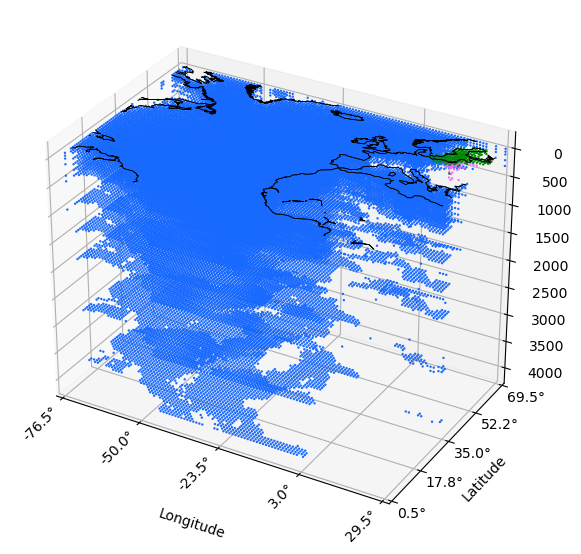

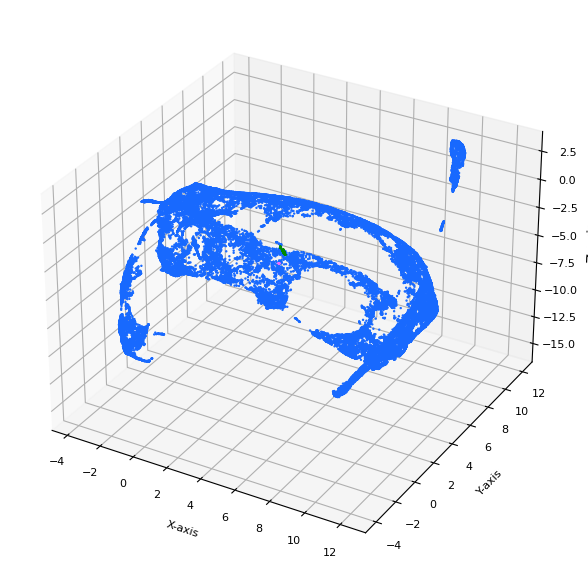

In [31]:
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_original_hyps, preproc=None, float_tol=1e-8)
temp = df_dbscan_labels.query(query_str).rename(columns={"minmax": "label"})

temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=-1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="label")
temp = temp[temp.label != -1]  # Remove noise label

coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_dbscan_original", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Plots on embedded data (MinMax-UMAP)

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:133: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


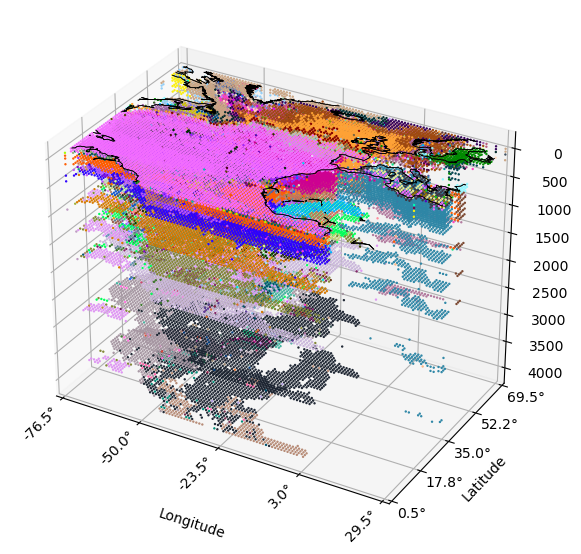

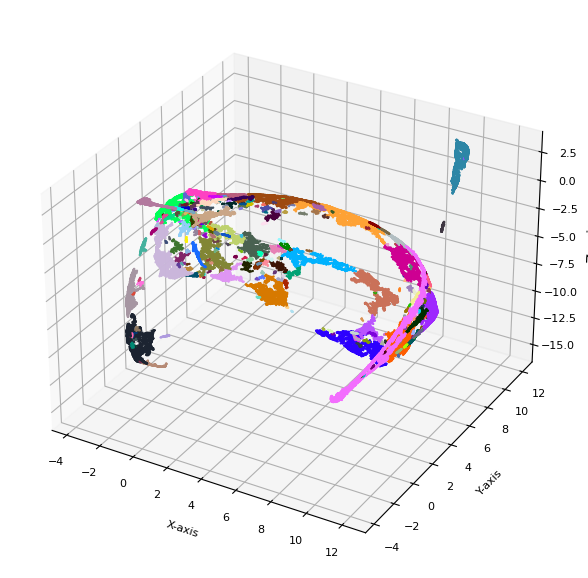

In [24]:
query_str = get_query_string_hyps_filter(hyp_dict=hyp_config.dbscan_umap_hyps, preproc=None, float_tol=1e-8)
temp = df_dbscan_labels.query(query_str).rename(columns={"minmax_umap": "label"})

temp.loc[:, ["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=-1)  # Rotate UMAP 
temp = color_code_labels(temp, column_name="label")
temp = temp[temp.label != -1]  # Remove noise label
coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_dbscan_umap", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)

## Confetti Plot

C:\Users\yvjennig\PycharmProjects\github\ocean_clustering_and_validation\visualisation\plotting.py:133: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


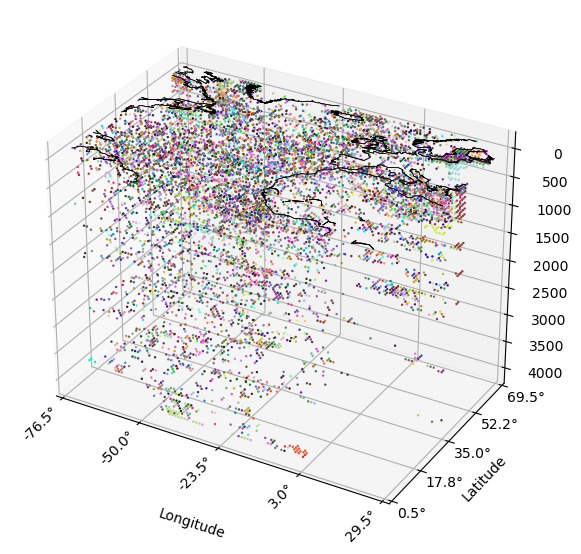

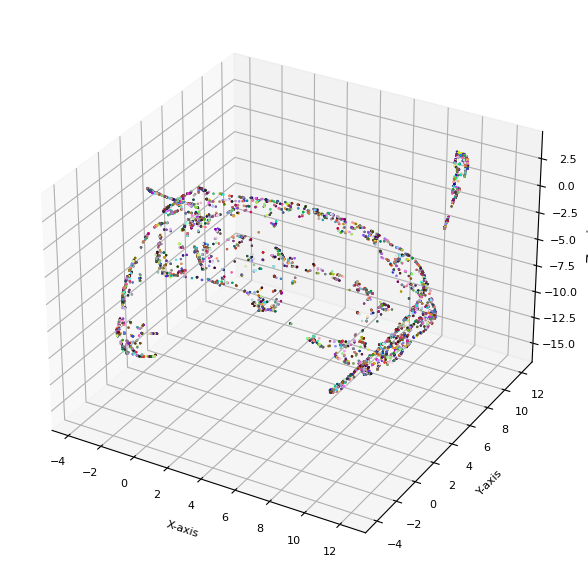

In [22]:
query_str = get_query_string_hyps_filter(hyp_dict={"eps": 0.01, "min_samples": 2}, preproc=None, float_tol=1e-8)
temp = df_dbscan_labels.query(query_str).rename(columns={"minmax_umap": "label"})

temp = color_code_labels(temp, column_name="label")
temp = temp[temp.label != -1]  # Remove noise label
temp[["e0", "e1", "e2"]] = rotate_umap(temp[["e0", "e1", "e2"]], x=0, y=0, z=180, factor=-1)

coupled_label_plot(temp, color_label="color", 
                   save_dir=config.output_dir_plots_high_res, suffix=f"_confetti", save_as=None, 
                   figsize=(6, 6), dpi=1000, 
                   zlabelpad=15, adjust_left=0, adjust_right=0.88)